In [1]:
library(readxl)
library(caret)
library(glmnet)
library(ggplotify)
library(randomForest)
library(igraph)
library(RColorBrewer)
library(ggfortify)
library(pROC)

Loading required package: ggplot2

Loading required package: lattice

Loading required package: Matrix

Loaded glmnet 4.1-6

randomForest 4.7-1.1

Type rfNews() to see new features/changes/bug fixes.


Attaching package: ‘randomForest’


The following object is masked from ‘package:ggplot2’:

    margin



Attaching package: ‘igraph’


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union


Type 'citation("pROC")' for a citation.


Attaching package: ‘pROC’


The following objects are masked from ‘package:stats’:

    cov, smooth, var




In [2]:
## Read excel 
became = data.frame(t(read_xlsx('../data/BECAME1_LipidomicData_lipidesidentifiés.xlsx',sheet=1)))

## Remove the first 10 columns (not lipids)
became_num = became[-c(1:10),]

## Cast data to numeric type 
rownames(became_num) = paste0('X',rownames(became_num))
for(i in 1:ncol(became_num)){became_num[,i]=as.numeric(became_num[,i])}


became = data.frame(t(read_xlsx('../data/BECAME1_LipidomicData_lipidesidentifiés.xlsx',sheet=1)))
became_meta = data.frame(t(became[c(1:4),]))

In [3]:
meta = read.csv('../data/merged_dataset_meta.csv')
response_name = 'cluster'

## Subset only the patients from the BECAME cohort
became_data = became_num[rownames(subset(meta,cohort=='BECAME' & group=='HFpEF')),]
became_data = data.frame(scale(log(became_data[,grepl('^X',colnames(became_data))])))


In [4]:
outputs = list()

In [13]:
set.seed(255)
index <- createDataPartition(became_data$response_var, p = 0.7, list = FALSE)
head(index)

Resample1
1
2
3
6
7
8


In [10]:
became_data$response_var = as.factor(as.numeric(meta[rownames(became_data),response_name]=='B1'))
index <- createDataPartition(became_data$response_var, p = 0.7, list = FALSE)

In [7]:
Train = became_data[index,]
Test = became_data[-index,]

Resample1
1
2
5
7
8
9
11
12
13
14


In [17]:
index <- createDataPartition(became_data$response_var, p = 0.7, list = FALSE,times=10)

In [14]:
index

for(i in 1:10){
    random_seed <- sample(1:10000, 1)
    set.seed(random_seed)
    
    ## Log transform the intensities 
    became_data$response_var = as.factor(as.numeric(meta[rownames(became_data),response_name]=='B1'))
    
    ## Create train/test indices 
    index <- createDataPartition(became_data$response_var, p = 0.7, list = FALSE)
    
    ## Define training data 
    became_data_train = became_data[index,]
    
    x = became_data[index,grepl('^X',colnames(became_data))]
    y = became_data[index,]$response_var
    
    cv_model <- cv.glmnet(as.matrix(x), y, alpha = 1,family='binomial')
    
    lambda_min <- cv_model$lambda.min
    lambda_1se <- cv_model$lambda.1se
    
    min_model <- glmnet(as.matrix(x), y, alpha = 1, lambda = lambda_min, family='binomial')
    co = coef(min_model)[,1]
    lambda_min_predictors = names(co[abs(co)>0])
    
    se_model <- glmnet(as.matrix(x), y, alpha = 1, lambda = lambda_1se, family='binomial')
    co = coef(se_model)[,1]
    lambda_se_predictors = names(co[abs(co)>0])
    
    preds_se =  predict(se_model, s = lambda_1se, newx = as.matrix(became_data[-index,grepl('^X',colnames(became_data))]),type='response')
    preds_min =  predict(min_model, s = lambda_min, newx = as.matrix(became_data[-index,grepl('^X',colnames(became_data))]),type='response')
    
    if(length(unique(round(preds_se)))>1 & length(unique(round(preds_min)))>1){
        
        cm_se = confusionMatrix(became_data[-index,]$response_var,as.factor(round(preds_se)))             
        cm_min = confusionMatrix(became_data[-index,]$response_var,as.factor(round(preds_min)))
        
        res = list(
            'min_lambda' = list('accuracy' = cm_min$byClass['Balanced Accuracy'],
                                'predictors' = lambda_min_predictors[-1]),
            'se_lambda' = list('accuracy' = cm_se$byClass['Balanced Accuracy'],
                                'predictors' = lambda_se_predictors[-1])
        )
        
        outputs[[as.character(random_seed)]] = res
        
    }
}
    

In [16]:
coef(se_model)

243 x 1 sparse Matrix of class "dgCMatrix"
                     s0
(Intercept) -1.56800764
X1           .         
X2           .         
X3           .         
X4           .         
X5           0.14797128
X6           .         
X7           .         
X8           .         
X9           .         
X10          .         
X11          .         
X12          .         
X13          .         
X14          .         
X15          .         
X16          .         
X17          .         
X18          .         
X19          .         
X20          .         
X21          .         
X22          .         
X23          .         
X24          .         
X25          .         
X26          .         
X27          .         
X28          .         
X29          .         
X30          .         
X31          .         
X32         -0.27039601
X33          .         
X34          .         
X35          .         
X36          .         
X37          .         
X38          .       

In [6]:
cols = colnames(became_data)[grepl('^X',colnames(became_data))]
vec = rep(0, length(cols))
names(vec) = cols
for(i in names(outputs)){
    vec[outputs[[i]][['se_lambda']][['predictors']]] = vec[outputs[[i]][['se_lambda']][['predictors']]]+1
}
vec = sort(vec[vec!=0]/length(outputs))

In [7]:
dim(became_data)

[1] 102 243

In [8]:
head(became_meta)

,Metabolites,Compound.Name,Lipid.ID,Lipid.suclasses
,<chr>,<chr>,<chr>,<chr>
X1,M371.3091T6.48,POS:371.3091@6.48,C14:0 Car,Acylcarnitines
X2,M369.2935T5.09,POS:369.2935@5.09,C14:1 Car,Acylcarnitines
X3,M399.3402T8.70,POS:399.3402@8.70,C16:0 Car,Acylcarnitines
X4,M427.3721T10.46,POS:427.3721@10.46,C18:0 Car,Acylcarnitines
X5,M425.3575T9.18,POS:425.3575@9.18,C18:1 Car,Acylcarnitines
X6,M423.3400T7.96,POS:423.3400@7.96,C18:2 Car,Acylcarnitines


Warning message:
“The `<scale>` argument of `guides()` cannot be `FALSE`. Use "none" instead as of ggplot2 3.3.4.”


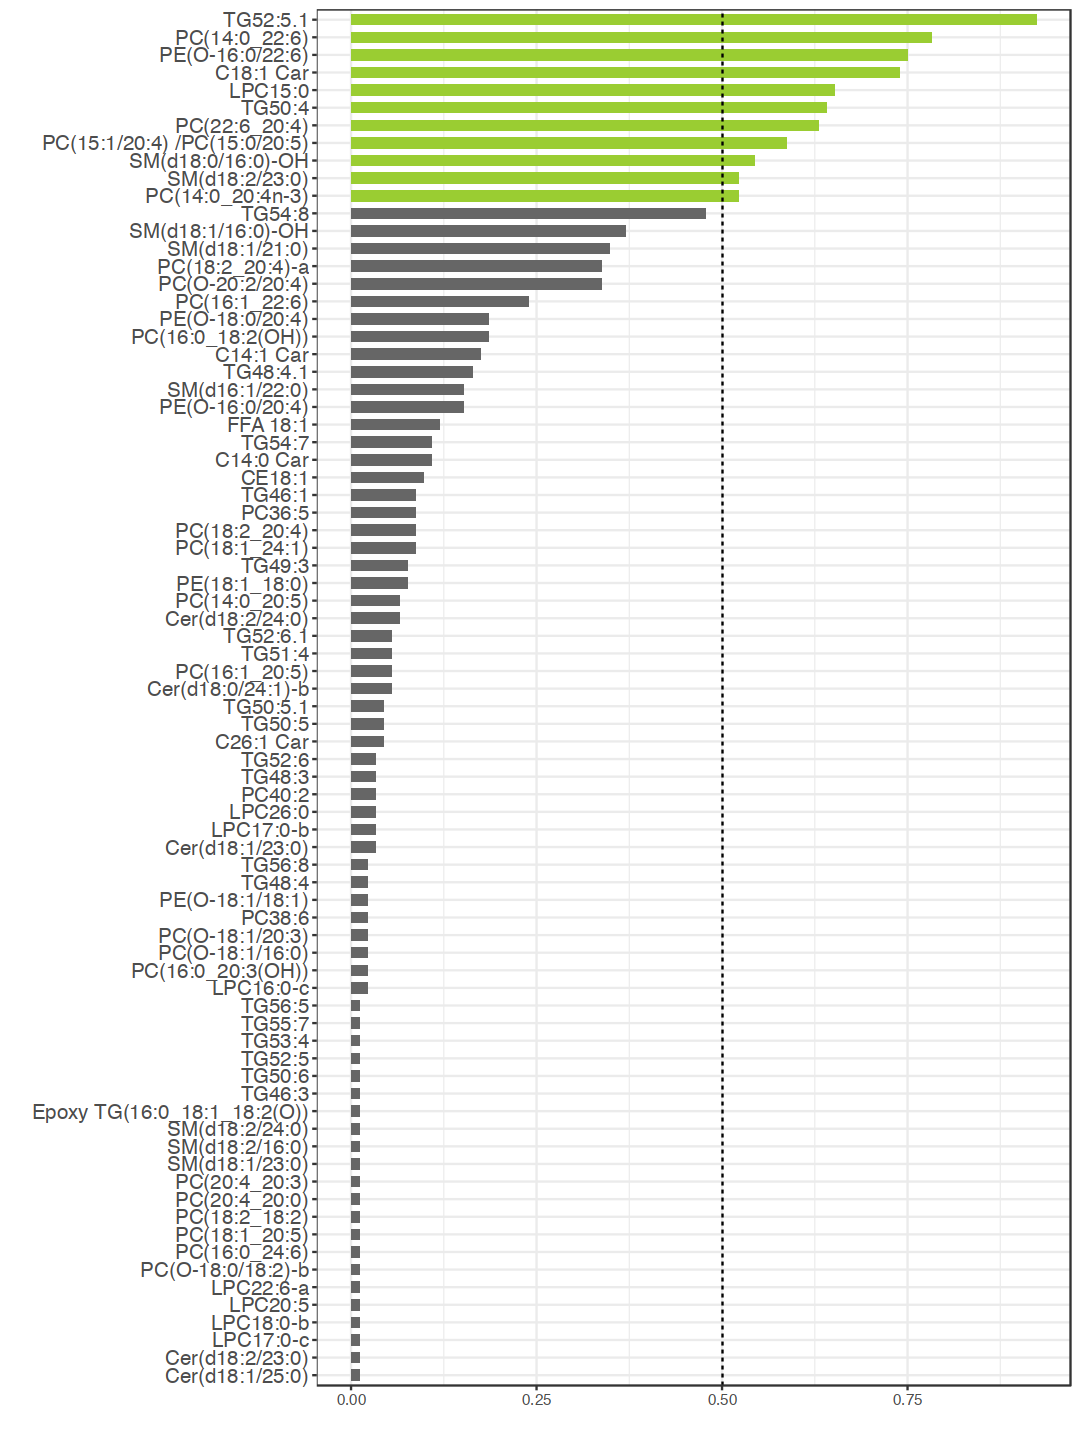

In [9]:
options(repr.plot.width = 9, repr.plot.height = 12)

vec_df = data.frame(vec)
vec_df$lipid_id = became_meta[rownames(vec_df),'Lipid.ID']
vec_df$lipid_id = make.unique(vec_df$lipid_id,sep='.')
vec_df$lipid_id = factor(vec_df$lipid_id,levels=vec_df[order(vec_df$vec),'lipid_id'])
ggplot(vec_df,aes(lipid_id,vec,fill=vec_df$vec>.5))+ 
    geom_col(width=.6)+
    theme_bw()+
    theme(axis.text.y=element_text(size=12))+
    geom_hline(yintercept=.5,linetype='dashed')+
    coord_flip()+
    scale_fill_manual(values=c('grey40','olivedrab3'))+
    guides(fill=F)+
    xlab('')+
    ylab('')
    

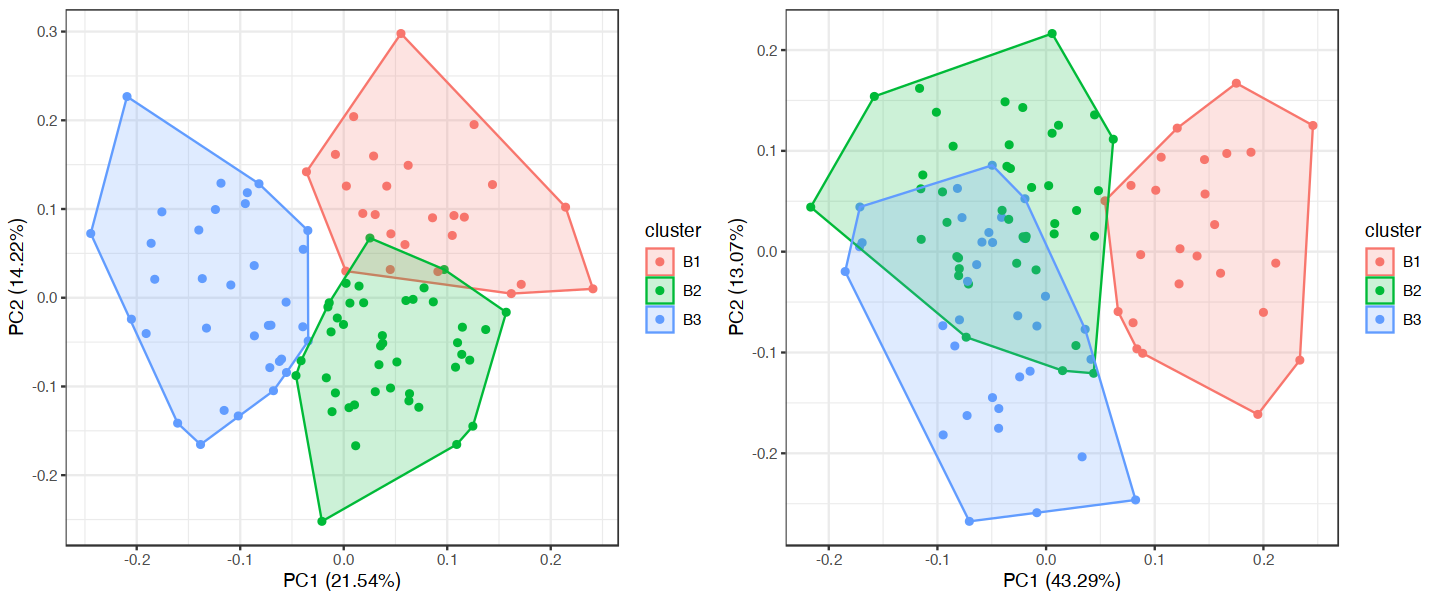

In [10]:
options(repr.plot.width = 12, repr.plot.height = 5)

p1 = autoplot(prcomp(became_data[,grepl('^X',colnames(became_data))]),data=meta[rownames(became_data),],col='cluster',frame=T)+theme_bw()
p2 = autoplot(prcomp(became_data[,names(vec[vec>=.5])]),data=meta[rownames(became_data),],col='cluster',frame=T)+theme_bw()
cowplot::plot_grid(p1,p2,ncol=2)

In [11]:
# Assuming `vec` and `outputs` already exist from your previous operations

index <- createDataPartition(became_data$response_var, p = 0.7, list = FALSE)

# Set the threshold at 50% (0.5)
threshold <- 0.5

# Identify features selected more than 50% of the time
frequent_features <- names(vec[vec  > threshold])

# Subset the original dataset to include only the frequently selected features
became_data_subset <- became_data[, c(frequent_features, "response_var")]

# Or you could repeat the LASSO logistic regression with predetermined features:
new_x <- as.matrix(became_data_subset[, frequent_features])
new_y <- became_data_subset[,]$response_var

# Train a new LASSO model
new_lasso_model <- cv.glmnet(new_x, new_y, alpha = 0, family = 'binomial')

# Coefficients for the new RIDGE model using lambda.min
new_lambda_min <- new_lasso_model$lambda.min
new_model_coef <- coef(new_lasso_model, s = new_lambda_min)

# Print the coefficients
print(new_model_coef)

12 x 1 sparse Matrix of class "dgCMatrix"
                    s1
(Intercept) -2.8048614
X92         -0.4967481
X160        -0.4958444
X166         0.5626614
X97         -0.4843831
X121        -0.3973676
X186        -0.5976672
X32         -0.5525114
X5           0.4773706
X127        -0.6709982
X94         -0.5868262
X197        -0.6775116


In [12]:
sort(rownames(new_model_coef)[-1])

[1] "X121" "X127" "X160" "X166" "X186" "X197" "X32"  "X5"   "X92"  "X94" 
[11] "X97"

In [13]:
preds = predict(new_lasso_model, s = new_lambda_min, newx = as.matrix(became_data[,frequent_features]),type='response')
confusionMatrix(became_data[,]$response_var,as.factor(round(preds)))

Confusion Matrix and Statistics

          Reference
Prediction  0  1
         0 77  0
         1  3 22
                                          
               Accuracy : 0.9706          
                 95% CI : (0.9164, 0.9939)
    No Information Rate : 0.7843          
    P-Value [Acc > NIR] : 6.9e-08         
                                          
                  Kappa : 0.9172          
                                          
 Mcnemar's Test P-Value : 0.2482          
                                          
            Sensitivity : 0.9625          
            Specificity : 1.0000          
         Pos Pred Value : 1.0000          
         Neg Pred Value : 0.8800          
             Prevalence : 0.7843          
         Detection Rate : 0.7549          
   Detection Prevalence : 0.7549          
      Balanced Accuracy : 0.9812          
                                          
       'Positive' Class : 0               
                                    

In [14]:
preds = predict(new_lasso_model, s = new_lambda_min, newx = as.matrix(became_data[,frequent_features]),type='response')

In [15]:
head(meta)

,id,group,cluster,cohort,preds
,<int>,<chr>,<chr>,<chr>,<chr>
X10299,10299,HFpEF,B3,BECAME,C3
X10301,10301,HFpEF,B2,BECAME,C2
X10302,10302,HFpEF,B2,BECAME,C2
X10303,10303,HFpEF,B2,BECAME,C2
X10304,10304,HFpEF,B1,BECAME,C1
X10305,10305,HFpEF,B1,BECAME,C1


In [16]:
df= data.frame(preds)
#preds[,1]=as.factor(preds[,1])
df$cluster = meta[rownames(preds),'preds']
df[,1] = -log10(1-df[,1])

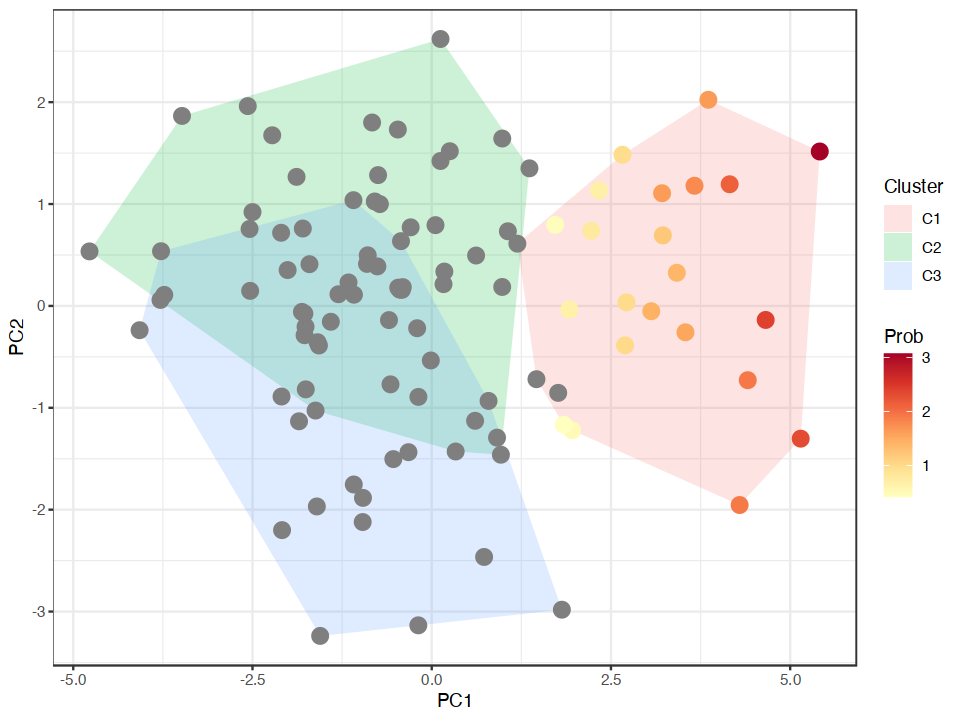

In [17]:
options(repr.plot.width = 8, repr.plot.height = 6)

library(plyr)
pca = prcomp(became_data[,frequent_features])$x
pca = data.frame(pca,df[rownames(pca),])
find_hull <- function(df) df[chull(df$PC1, df$PC2), ]
hulls <- ddply(pca, "cluster", find_hull)
pca$s1[pca$s1<0.3]=NA
ggplot(pca,aes(PC1,PC2))+theme_bw()+ 
geom_polygon(aes(fill=cluster),data = hulls, alpha = 0.2)+
    geom_point(aes(col=s1),size=4)+
    scale_color_gradientn(colors=c(rev(brewer.pal(11,'RdYlBu'))[-c(1:5)]))+labs(col='Prob',fill='Cluster')

Setting levels: control = 0, case = 1

Setting direction: controls < cases



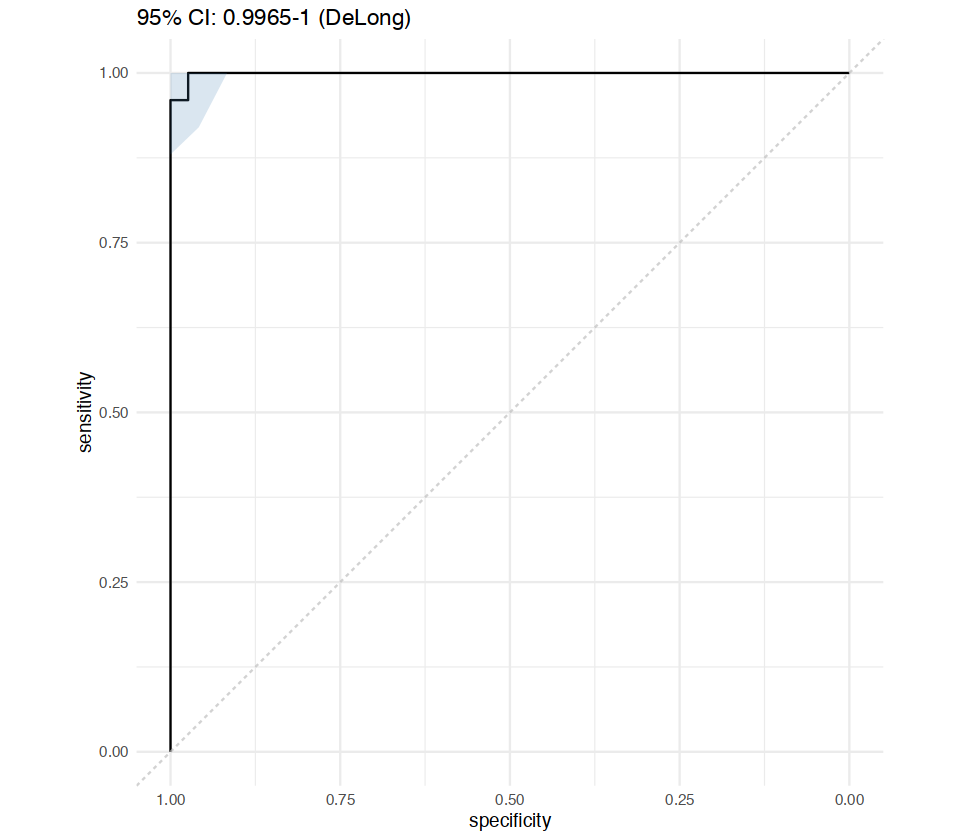

In [18]:
options(repr.plot.width = 8, repr.plot.height = 7)

obj <- roc(became_data$response_var,as.numeric(preds), ci=TRUE, plot=FALSE)
ciobj <- ci.se(obj, specificities=seq(0, 1, l=25))
dat.ci <- data.frame(x = as.numeric(rownames(ciobj)),
                     lower = ciobj[, 1],
                     upper = ciobj[, 3])

proc = ggroc(obj) + 
    theme_minimal() + 
    geom_abline(slope=1, intercept = 1, linetype = "dashed", alpha=0.7, color = "grey") + 
    coord_equal() + 
    geom_ribbon(data = dat.ci, aes(x = x, ymin = lower, ymax = upper), fill = "steelblue", alpha= 0.2) + 
    ggtitle(capture.output(obj$ci))
proc

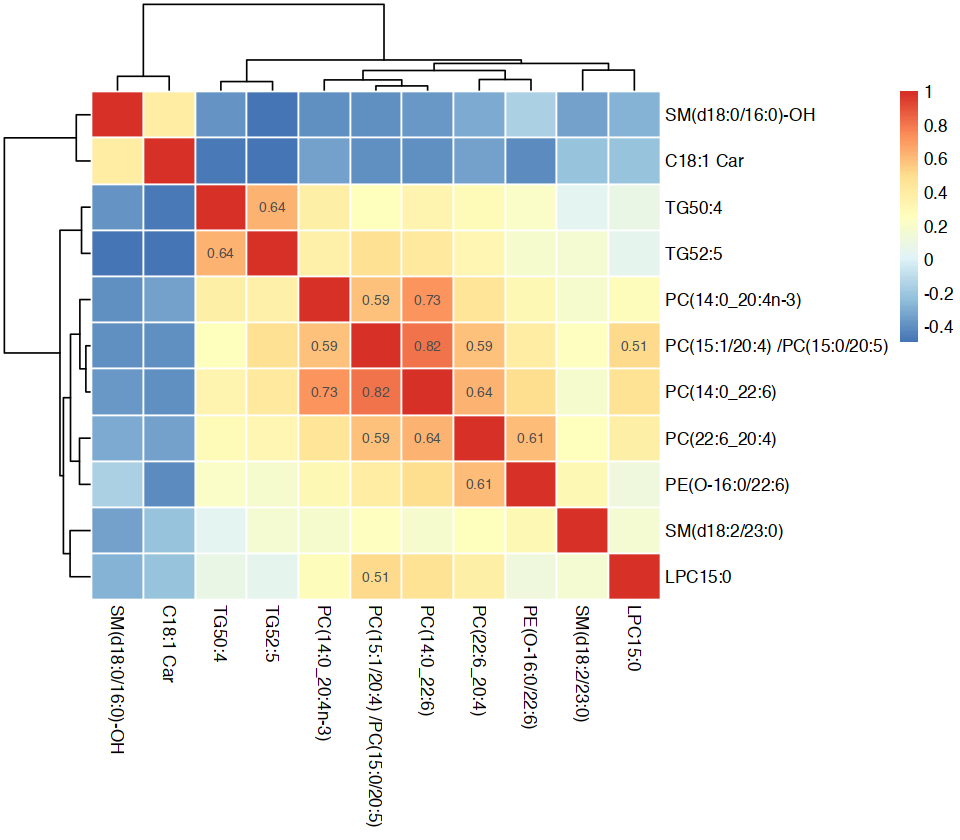

In [19]:
options(repr.plot.width = 8, repr.plot.height = 7)


cor_mat = cor( became_data[, c(frequent_features)])

became_meta$Lipid.ID = make.unique(became_meta$Lipid.ID)
rownames(cor_mat) = became_meta[rownames(cor_mat),'Lipid.ID']
colnames(cor_mat) = became_meta[colnames(cor_mat),'Lipid.ID']

num_mat = round(cor_mat,digits=2)
num_mat[num_mat==1|num_mat<=.5] = ''

pheatmap::pheatmap(cor_mat,border_col='white',clustering_method='ward.D2',display_number=num_mat)

In [20]:
became_meta[names(vec[vec>.5]),]

,Metabolites,Compound.Name,Lipid.ID,Lipid.suclasses
,<chr>,<chr>,<chr>,<chr>
X92,M753.5341T19.11,POS:753.5341@19.11,PC(14:0_20:4n-3),Phosphatidylcholines
X160,M798.6643T31.28,POS:798.6643@31.28,SM(d18:2/23:0),Sphingomyelins
X166,M720.5818T20.54,POS:720.5818@20.54,SM(d18:0/16:0)-OH,Oxydized Sphingomyelins
X97,M765.5336T18.76,POS:765.5336@18.76,PC(15:1/20:4) /PC(15:0/20:5),Phosphatidylcholines
X121,M853.5652T19.50,POS:853.5652@19.50,PC(22:6_20:4),Phosphatidylcholines
X186,M843.7354T48.11,POS:843.7354@48.11,TG50:4,Triglycerides
X32,M481.3235T7.62,POS:481.3235@7.62,LPC15:0,Lysophosphatidylcholines
X5,M425.3575T9.18,POS:425.3575@9.18,C18:1 Car,Acylcarnitines
X127,M749.5397T24.69,POS:749.5397@24.69,PE(O-16:0/22:6),Phosphatidylethanolamines ethers


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


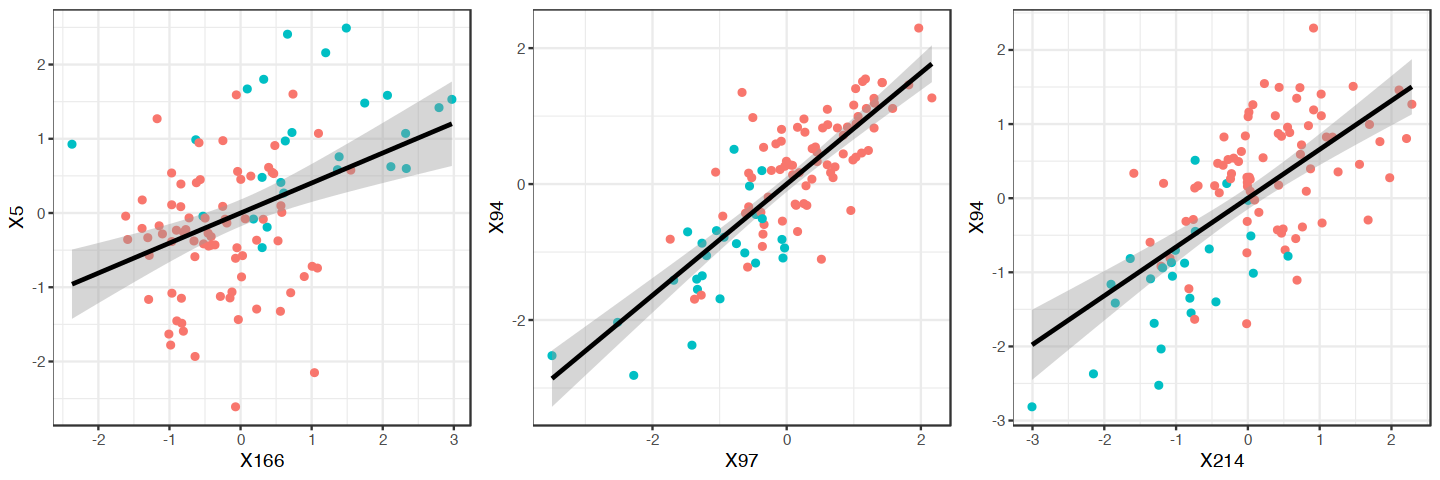

In [21]:
options(repr.plot.width = 12, repr.plot.height = 4)

p1 = ggplot(became_data,aes(X166,X5,col=response_var))+geom_point()+theme_bw()+geom_smooth(method='lm',col='black')+guides(col=F)
p2 = ggplot(became_data,aes(X97,X94,col=response_var))+geom_point()+theme_bw()+geom_smooth(method='lm',col='black')+guides(col=F)
p3 = ggplot(became_data,aes(X214,X94,col=response_var))+geom_point()+theme_bw()+geom_smooth(method='lm',col='black')+guides(col=F)
cowplot::plot_grid(p1,p2,p3,ncol=3)

In [40]:
mat <- cor(became_data[,grepl('^X',colnames(became_data))])
lipid_id = rownames(mat)


In [41]:
my_color

<NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> 
  NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA 
<NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> 
  NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA 
<NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> 
  NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA 
<NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> 
  NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA 
<NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> 
  NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA 
<NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> 
  NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA 
<NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> 
  NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA 
<NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> 
  NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA 
<NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> 
  NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA 
<NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> 
  NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA 
<NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> 
  NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA 
<NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> 
  NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA 
<NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> 
  NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA 
<NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> 
  NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA 
<NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> 
  NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA   NA 
<NA> <NA> 
  NA   NA

In [42]:
became_meta[rownames(mat),]$Lipid.suclasses

[1] "Acylcarnitines"                   "Acylcarnitines"                  
  [3] "Acylcarnitines"                   "Acylcarnitines"                  
  [5] "Acylcarnitines"                   "Acylcarnitines"                  
  [7] "Acylcarnitines"                   "Acylcarnitines"                  
  [9] "Ceramides"                        "Ceramides"                       
 [11] "Ceramides"                        "Ceramides"                       
 [13] "Ceramides"                        "Ceramides"                       
 [15] "Ceramides"                        "Ceramides"                       
 [17] "Cholesteryl esters"               "Cholesteryl esters"              
 [19] "Cholesteryl esters"               "Cholesteryl esters"              
 [21] "Cholesteryl esters"               "Cholesteryl esters"              
 [23] "Free fatty acids"                 "Free fatty acids"                
 [25] "Free fatty acids"                 "Free fatty acids"                
 [27] "Lysophosphatidylcholine ethers"   "Lysophosphatidylcholine ethers"  
 [29] "Lysophosphatidylcholine ethers"   "Lysophosphatidylcholine ethers"  
 [31] "Lysophosphatidylcholine ethers"   "Lysophosphatidylcholines"        
 [33] "Lysophosphatidylcholines"         "Lysophosphatidylcholines"        
 [35] "Lysophosphatidylcholines"         "Lysophosphatidylcholines"        
 [37] "Lysophosphatidylcholines"         "Lysophosphatidylcholines"        
 [39] "Lysophosphatidylcholines"         "Lysophosphatidylcholines"        
 [41] "Lysophosphatidylcholines"         "Lysophosphatidylcholines"        
 [43] "Lysophosphatidylcholines"         "Lysophosphatidylcholines"        
 [45] "Lysophosphatidylcholines"         "Lysophosphatidylcholines"        
 [47] "Lysophosphatidylcholines"         "Lysophosphatidylcholines"        
 [49] "Lysophosphatidylcholines"         "Lysophosphatidylcholines"        
 [51] "Lysophosphatidylcholines"         "Lysophosphatidylcholines"        
 [53] "Lysophosphatidylcholines"         "Lysophosphatidylcholines"        
 [55] "Lysophosphatidylcholines"         "Lysophosphatidylcholines"        
 [57] "Lysophosphatidylethanolamines"    "Oxidized Phosphatidylcholines"   
 [59] "Oxidized Phosphatidylcholines"    "Oxidized Phosphatidylcholines"   
 [61] "Oxidized Phosphatidylcholines"    "Phosphatidylcholine ethers"      
 [63] "Phosphatidylcholine ethers"       "Phosphatidylcholine ethers"      
 [65] "Phosphatidylcholine ethers"       "Phosphatidylcholine ethers"      
 [67] "Phosphatidylcholine ethers"       "Phosphatidylcholine ethers"      
 [69] "Phosphatidylcholine ethers"       "Phosphatidylcholine ethers"      
 [71] "Phosphatidylcholine ethers"       "Phosphatidylcholine ethers"      
 [73] "Phosphatidylcholine ethers"       "Phosphatidylcholine ethers"      
 [75] "Phosphatidylcholine ethers"       "Phosphatidylcholine ethers"      
 [77] "Phosphatidylcholine ethers"       "Phosphatidylcholine ethers"      
 [79] "Phosphatidylcholine ethers"       "Phosphatidylcholine ethers"      
 [81] "Phosphatidylcholine ethers"       "Phosphatidylcholine ethers"      
 [83] "Phosphatidylcholine ethers"       "Phosphatidylcholine ethers"      
 [85] "Phosphatidylcholine ethers"       "Phosphatidylcholine ethers"      
 [87] "Phosphatidylcholine ethers"       "Phosphatidylcholine ethers"      
 [89] "Phosphatidylcholine ethers"       "Phosphatidylcholines"            
 [91] "Phosphatidylcholines"             "Phosphatidylcholines"            
 [93] "Phosphatidylcholines"             "Phosphatidylcholines"            
 [95] "Phosphatidylcholines"             "Phosphatidylcholines"            
 [97] "Phosphatidylcholines"             "Phosphatidylcholines"            
 [99] "Phosphatidylcholines"             "Phosphatidylcholines"            
[101] "Phosphatidylcholines"             "Phosphatidylcholines"            
[103] "Phosphatidylcholines"             "Phosphatidylcholines"            
[105] "Phosphatidylcholines"             "Phosphat

In [43]:
n <- nlevels(as.factor(became_meta$Lipid.suclasses))
qual_col_pals = brewer.pal.info[brewer.pal.info$category == 'qual',]
col_vector = unlist(mapply(brewer.pal, qual_col_pals$maxcolors, rownames(qual_col_pals)))
col_vector = sample(col_vector, n)
names(col_vector) = unique(became_meta[rownames(mat),'Lipid.suclasses'])

# Map the color to cylinders
my_color <- col_vector[became_meta[rownames(mat),]$Lipid.suclasses]


In [45]:
pca_coords = as.matrix(prcomp(t(became_data[,rownames(mat)]))$x[,1:2])

In [52]:
became_meta$Lipid.ID = make.unique(became_meta$Lipid.ID)
rownames(mat) = became_meta[rownames(mat),'Lipid.ID']
colnames(mat) = became_meta[colnames(mat),'Lipid.ID']

In [53]:
became_meta[frequent_features,]

,Metabolites,Compound.Name,Lipid.ID,Lipid.suclasses
,<chr>,<chr>,<chr>,<chr>
X92,M753.5341T19.11,POS:753.5341@19.11,PC(14:0_20:4n-3),Phosphatidylcholines
X160,M798.6643T31.28,POS:798.6643@31.28,SM(d18:2/23:0),Sphingomyelins
X166,M720.5818T20.54,POS:720.5818@20.54,SM(d18:0/16:0)-OH,Oxydized Sphingomyelins
X97,M765.5336T18.76,POS:765.5336@18.76,PC(15:1/20:4) /PC(15:0/20:5),Phosphatidylcholines
X121,M853.5652T19.50,POS:853.5652@19.50,PC(22:6_20:4),Phosphatidylcholines
X186,M843.7354T48.11,POS:843.7354@48.11,TG50:4,Triglycerides
X32,M481.3235T7.62,POS:481.3235@7.62,LPC15:0,Lysophosphatidylcholines
X5,M425.3575T9.18,POS:425.3575@9.18,C18:1 Car,Acylcarnitines
X127,M749.5397T24.69,POS:749.5397@24.69,PE(O-16:0/22:6),Phosphatidylethanolamines ethers


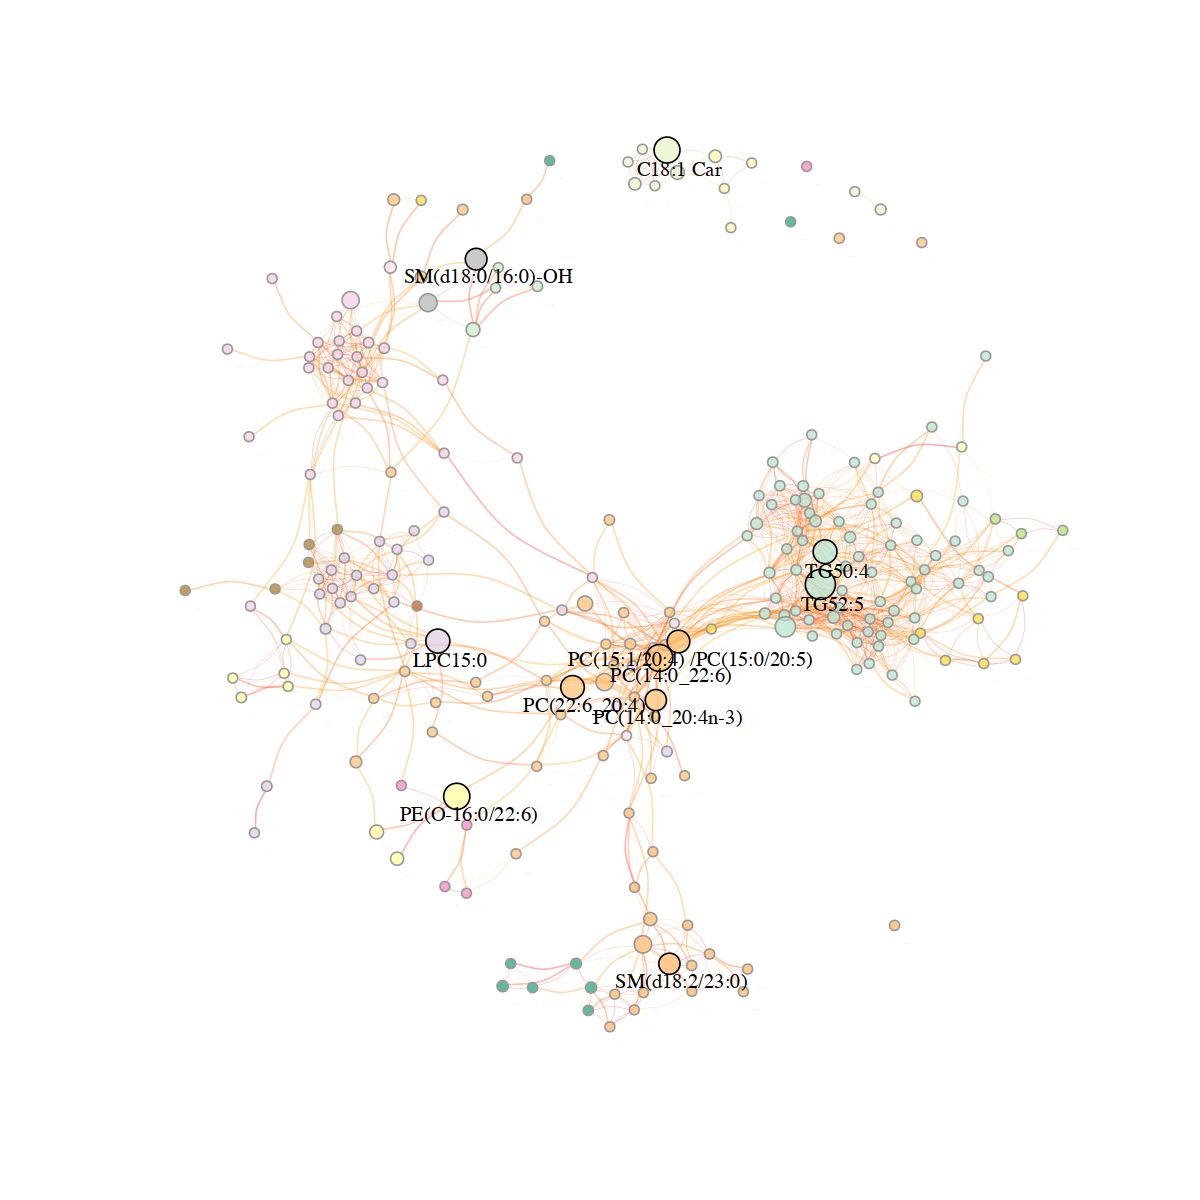

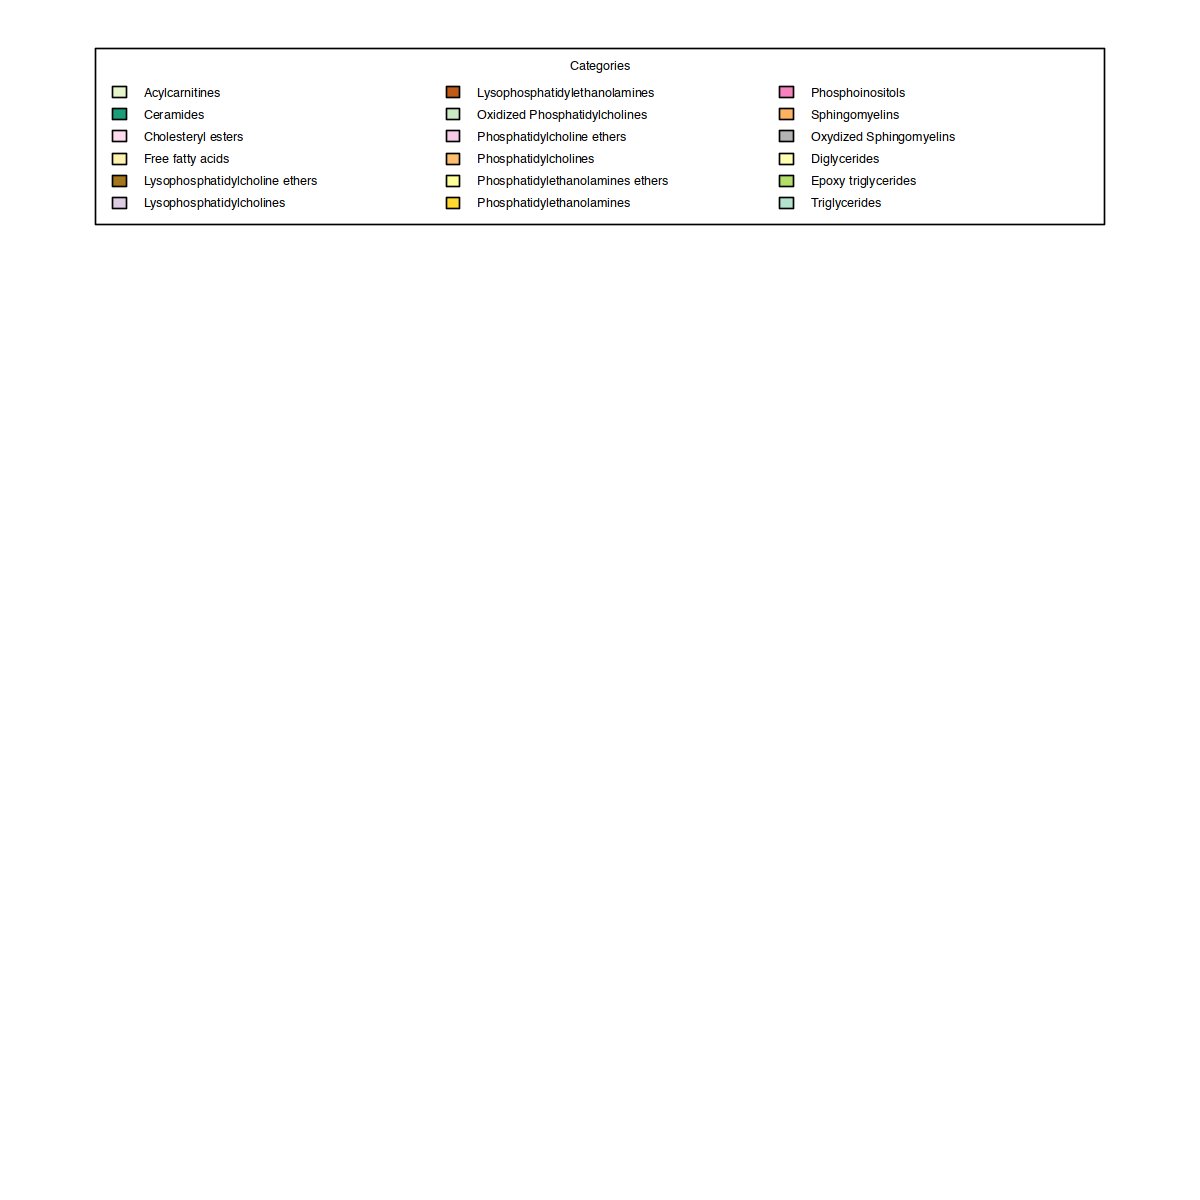

In [50]:
frequent_features <- names(vec[vec  > .5])
options(repr.plot.width = 10, repr.plot.height = 10)

border_col = c('1'='black','0'='grey60')
border_col_vec = border_col[as.character(as.numeric(rownames(mat)%in%became_meta[frequent_features,'Lipid.ID']))]

vertex_size = vec
#vertex_size_vec = vertex_size[as.character(as.numeric(rownames(mat)%in%became_meta[frequent_features,'Lipid.ID']))]
vertex_size_vec = vec[lipid_id]
vertex_size_vec[is.na(vertex_size_vec)] = 0.001


label_size = c('1'=1,'0'=1e-10)
label_size_vec = label_size[as.character(as.numeric(rownames(mat)%in%became_meta[frequent_features,'Lipid.ID']))]



mat[mat<0.55] <- 0
network <- graph_from_adjacency_matrix(abs(mat), weighted=T, mode="undirected", diag=F)

c_scale <- colorRamp(rev(c('darkred','red',
                        'darkorange1','yellow',
                           'grey90','grey90')))

edge_colors = apply(c_scale(E(network)$weight), 1, function(x) rgb(x[1]/255,x[2]/255,x[3]/255) )
                         
co <- layout_with_fr(network, 
                     coords=pca_coords)                         
                         
set.seed(123)                    
plot(network,
     
     layout = co,

    # === vertex
    vertex.color=adjustcolor(my_color, alpha.f = .7),          # Node color
    vertex.frame.color = border_col_vec,                 # Node border color
    vertex.shape="circle",                        # One of “none”, “circle”, “square”, “csquare”, “rectangle” “crectangle”, “vrectangle”, “pie”, “raster”, or “sphere”
    vertex.size=vertex_size_vec*5+2,                               # Size of the node (default is 15)
    vertex.size2=NA,                              # The second size of the node (e.g. for a rectangle)

    # === vertex label
    vertex.label.color='black',
    vertex.label.family="Times",  
     # Font family of the label (e.g.“Times”, “Helvetica”)
    vertex.label.font=1,                          # Font: 1 plain, 2 bold, 3, italic, 4 bold italic, 5 symbol
    vertex.label.cex=label_size_vec,                           # Font size (multiplication factor, device-dependent)
    vertex.label.degree=1 ,    
    vertex.label.dist=.7, # The position of the label in relation to the vertex (use pi)

    # === Edge
    edge.width=scale(1-edge.betweenness(network)),
    edge.color=adjustcolor(edge_colors, alpha.f = .3),# Edge width, defaults to 1
    edge.arrow.size=1,                            # Arrow size, defaults to 1
    edge.arrow.width=1,                           # Arrow width, defaults to 1
    edge.lty="solid",                             # Line type, could be 0 or “blank”, 1 or “solid”, 2 or “dashed”, 3 or “dotted”, 4 or “dotdash”, 5 or “longdash”, 6 or “twodash”
    edge.curved=0.3    ,                          # Edge curvature, range 0-1 (FALSE sets it to 0, TRUE to 0.5)
    )
par(mar = c(5, 5, 2, 5))  # Adjust the margin to leave space for the legend
# Plotting an empty plot to create space for the legend
plot(1, type = "n", axes = FALSE, xlab = "", ylab = "")
# Adding a legend
legend("top", legend = names(col_vector), fill = col_vector, title = "Categories",ncol = 3, cex = 0.6, xpd = TRUE)
   

In [55]:
became_meta[names(vec[vec>.5]),]

,Metabolites,Compound.Name,Lipid.ID,Lipid.suclasses
,<chr>,<chr>,<chr>,<chr>
X92,M753.5341T19.11,POS:753.5341@19.11,PC(14:0_20:4n-3),Phosphatidylcholines
X160,M798.6643T31.28,POS:798.6643@31.28,SM(d18:2/23:0),Sphingomyelins
X166,M720.5818T20.54,POS:720.5818@20.54,SM(d18:0/16:0)-OH,Oxydized Sphingomyelins
X97,M765.5336T18.76,POS:765.5336@18.76,PC(15:1/20:4) /PC(15:0/20:5),Phosphatidylcholines
X121,M853.5652T19.50,POS:853.5652@19.50,PC(22:6_20:4),Phosphatidylcholines
X186,M843.7354T48.11,POS:843.7354@48.11,TG50:4,Triglycerides
X32,M481.3235T7.62,POS:481.3235@7.62,LPC15:0,Lysophosphatidylcholines
X5,M425.3575T9.18,POS:425.3575@9.18,C18:1 Car,Acylcarnitines
X127,M749.5397T24.69,POS:749.5397@24.69,PE(O-16:0/22:6),Phosphatidylethanolamines ethers


Using cluster as id variables



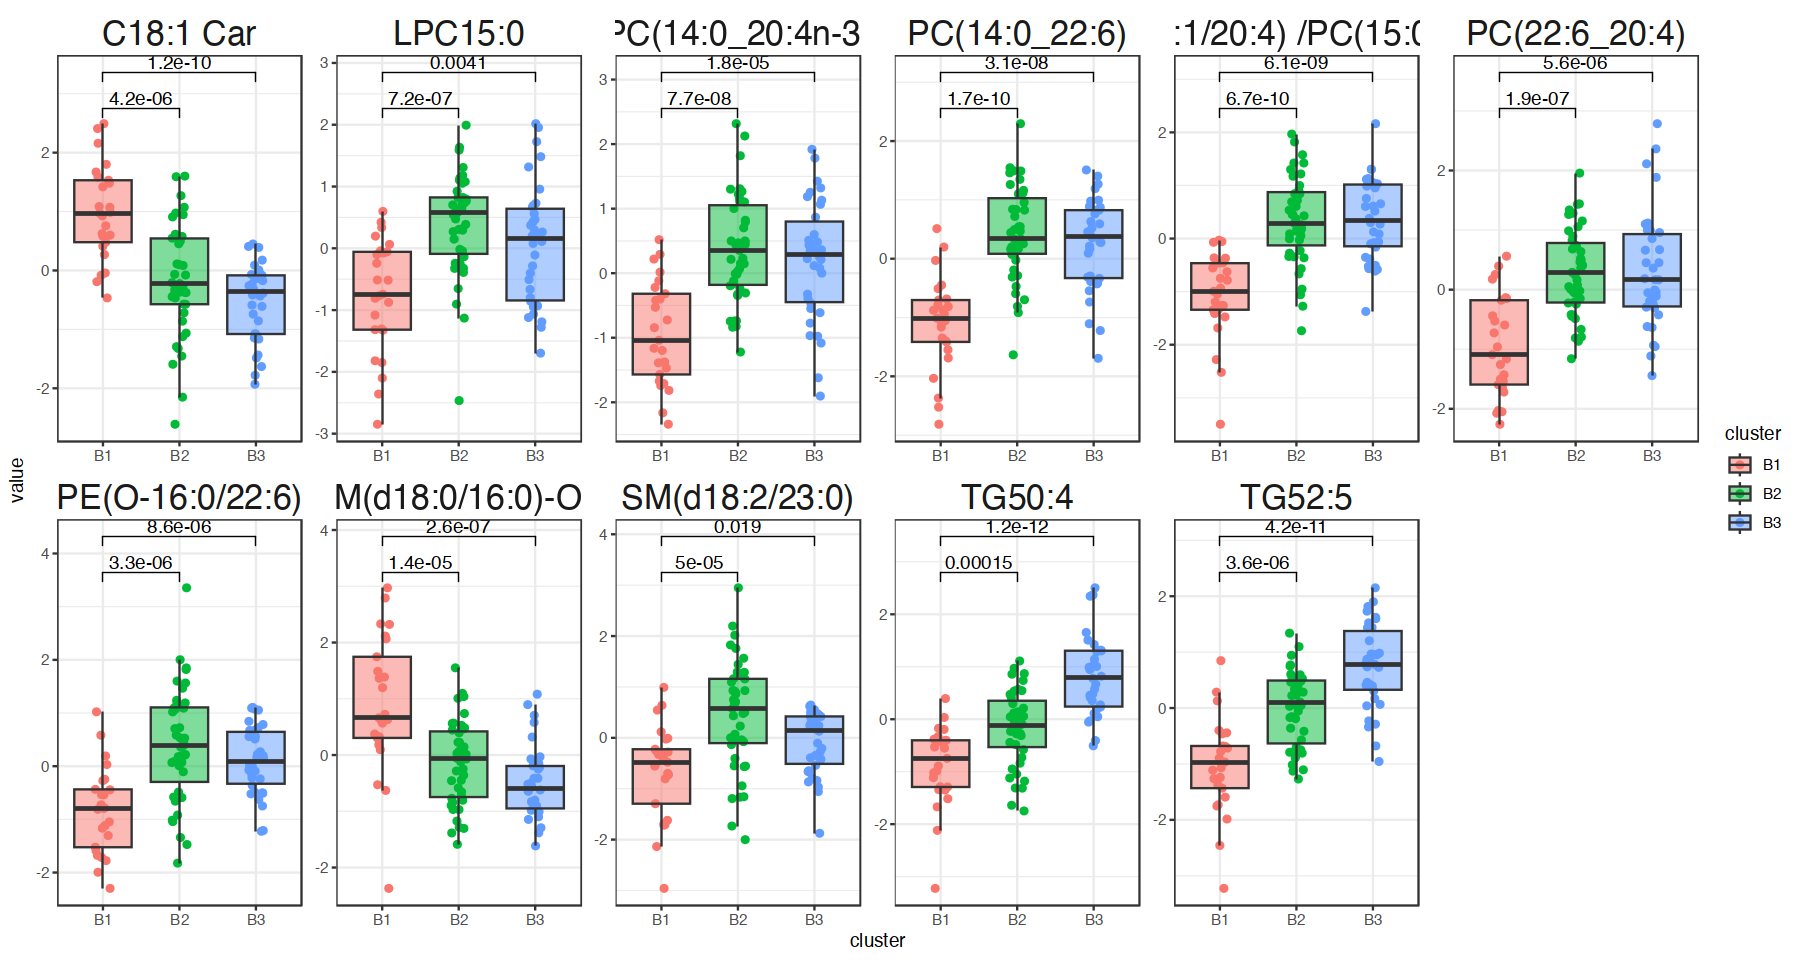

In [57]:
options(repr.plot.width = 15, repr.plot.height = 8)
library(ggpubr)
frequent_features <- names(vec[vec  > .5])

df_plot = cbind(became_data[,frequent_features],meta[rownames(became_data),'cluster'])
colnames(df_plot)[ncol(df_plot)] = 'cluster'
m = reshape2::melt(df_plot)

m$lipid_name = became_meta[as.character(m$variable),'Lipid.ID']
ggplot(m,aes(cluster,value,fill=cluster))+
    geom_point(aes(col=cluster),position=position_jitter(width=.1))+
    geom_boxplot(alpha=.5,outlier.shape=NA)+
    facet_wrap(~lipid_name,scales='free',ncol=6)+theme_bw()+theme(strip.background=element_blank(),strip.text=element_text(size=20))+stat_compare_means(comparison=list(c('B1','B2'),c('B1','B3')))

In [58]:
dim(became_meta)

[1] 242   4